In [47]:
%pip install qiskit pylatexenc

from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, Parameter
from qiskit.quantum_info import Statevector, Operator
import pylatexenc
import math

from qiskit.circuit.library import QFTGate, UnitaryGate, MCPhaseGate
from qiskit.circuit.library import DraperQFTAdder

import matplotlib.pyplot as plt
import numpy as np

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


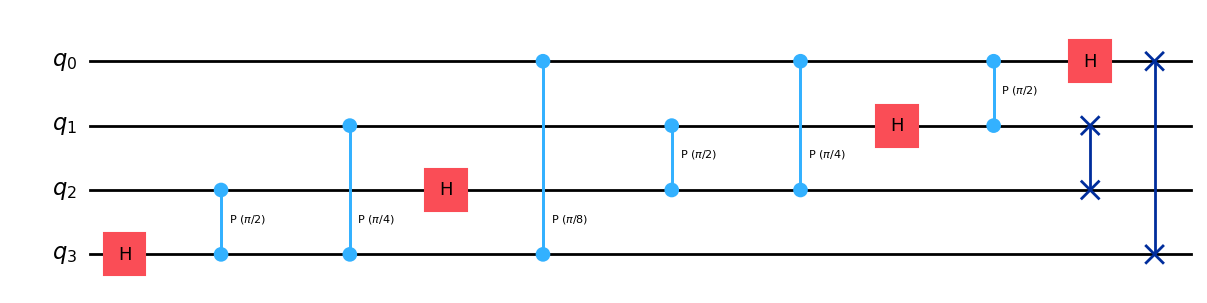

In [48]:
def make_FrrT(n):
    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)
    for i in range(n - 1, -1, -1):
        qc.h(qr[i])
        for j in range(i - 1, -1, -1):
            qc.cp(2 * math.pi / 2**(i - j + 1), qr[j], qr[i])
    for i in range(n // 2):
        qc.swap(qr[i], qr[n - 1 - i])
    return qc

display(make_FrrT(4).draw("mpl"))


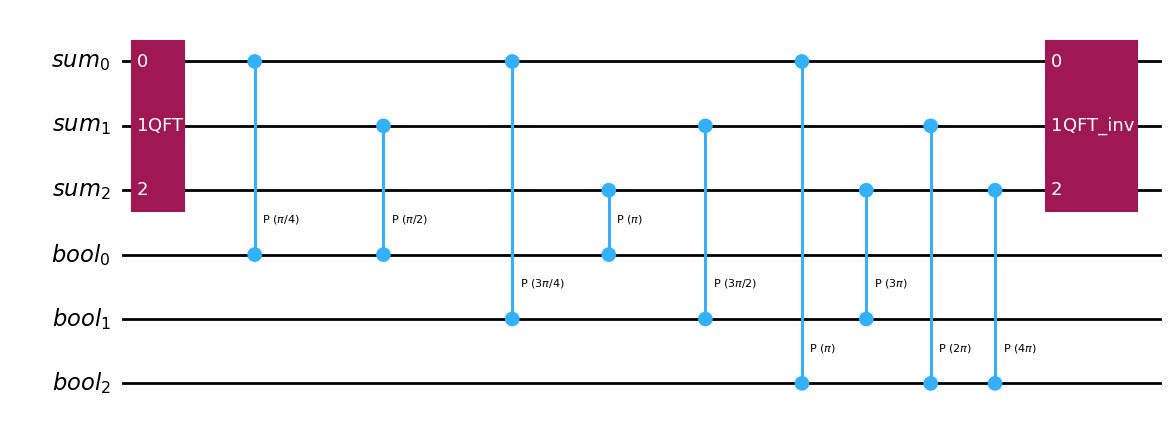

In [49]:
def make_adder(n, L):
    qr_sum = QuantumRegister(n, "sum")
    qr_bool = QuantumRegister(len(L), "bool")
    qc = QuantumCircuit(qr_sum, qr_bool)

    qc.append(make_FrrT(n).to_gate(label="QFT"), qr_sum)

    for k, val in enumerate(L):
        for i in range(n):
            angle = math.pi * val / 2**(n - i - 1)
            qc.append(MCPhaseGate(angle, 1), [qr_bool[k], qr_sum[i]])

    qc.append(make_FrrT(n).inverse().to_gate(label="QFT_inv"), qr_sum)

    return qc

display(make_adder(3, [1, 3, 4]).draw("mpl"))


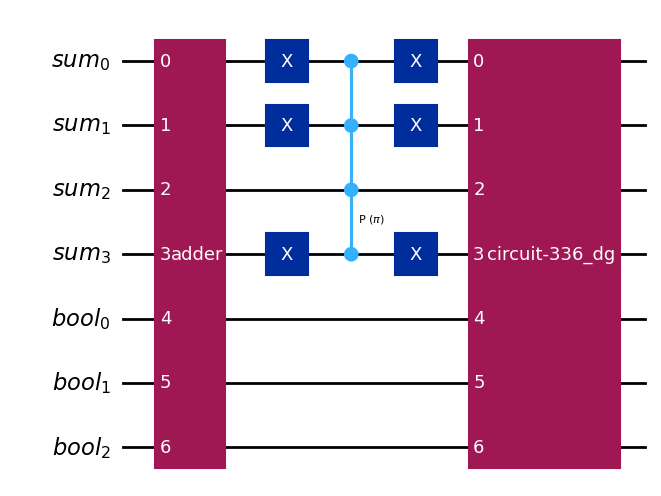

In [50]:
def make_U(n, L, target):
    qr_sum = QuantumRegister(n, "sum")
    qr_bool = QuantumRegister(len(L), "bool")
    qc = QuantumCircuit(qr_sum, qr_bool)

    adder = make_adder(n, L).to_gate(label="adder")
    qc.append(adder, qr_sum[:] + qr_bool[:])

    for i in range(n):
        if not ((target >> i) & 1):
            qc.x(qr_sum[i])
    qc.append(MCPhaseGate(math.pi, n - 1), qr_sum[:])
    for i in range(n):
        if not ((target >> i) & 1):
            qc.x(qr_sum[i])

    qc.append(adder.inverse(), qr_sum[:] + qr_bool[:])

    return qc

display(make_U(4, [1, 3, 4], 4).draw("mpl"))


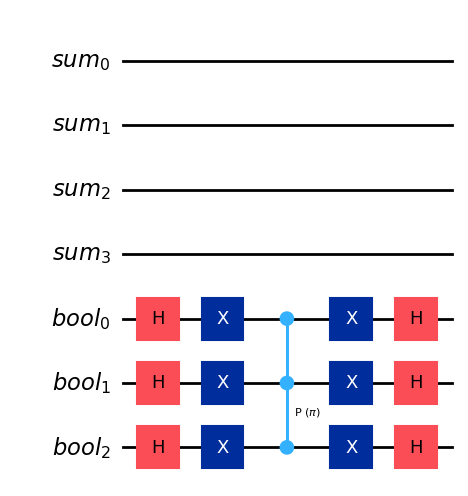

In [51]:
def make_diffuser(n, L):
    qr_sum = QuantumRegister(n, "sum")
    qr_bool = QuantumRegister(len(L), "bool")
    qc = QuantumCircuit(qr_sum, qr_bool)

    nb = len(L)
    qc.h(qr_bool)
    qc.x(qr_bool)
    qc.append(MCPhaseGate(math.pi, nb - 1), qr_bool[:])
    qc.x(qr_bool)
    qc.h(qr_bool)

    return qc

display(make_diffuser(4, [1, 3, 4]).draw("mpl"))


In [ ]:
def grover_subset_sum(target, L):
    n = math.ceil(math.log2(sum(L) + 1)) if sum(L) > 0 else 1
    nb = len(L)

    qr_sum = QuantumRegister(n, "sum")
    qr_bool = QuantumRegister(nb, "bool")
    qc = QuantumCircuit(qr_sum, qr_bool)

    qc.h(qr_bool)

    U = make_U(n, L, target).to_gate(label="U")
    D = make_diffuser(n, L).to_gate(label="D")
    num_iter = round(math.pi / 4 * math.sqrt(2**nb))
    for _ in range(num_iter):
        qc.append(U, qr_sum[:] + qr_bool[:])
        qc.append(D, qr_sum[:] + qr_bool[:])

    bool_probs = Statevector(qc).probabilities(list(range(n, n + nb)))
    threshold = 1 / (2 * 2**nb)
    return [(val, prob) for val, prob in enumerate(bool_probs) if prob > threshold]

L = [1, 3, 4]
target = 4
for val, prob in grover_subset_sum(target, L):
    subset = [L[k] for k in range(len(L)) if (val >> k) & 1]
    print(f"bool={val:0{len(L)}b}  subset={subset}  prob={prob:.4f}")
